<a href="https://colab.research.google.com/github/leo6930/leo6930/blob/main/projects/2025/Seoul%20Residential%20Satisfaction%20Prediction%20and%20Factor%20Analysis/Seoul_satisfication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 모델구현 및 모델 학습

In [ ]:
# ================== 0. 필수 패키지 ==================
import pandas as pd, numpy as np, joblib, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# ================== 1. CSV 경로 ==================
FILE_PATH = "/content/drive/MyDrive/AI/서울서베이_MinMax.csv"
TARGET_COL = "종합만족도"

# ================== 2. 데이터 로드 ==================
df = pd.read_csv(FILE_PATH, encoding="utf-8")

# 범주형/연속형 분리
cat_numeric = [
    "구코드", "주택형태", "주거점유형태", "통근/통학 여부", "통근/통학 지역",
    "통근/통학 지역_다른 구의 경우", "주로 이용하는 교통수단",
    "통근/통학 환경에 대한 전반적 만족도", "녹지환경 만족도", "야간 보행시 안전도",
    "문화환경 만족도_문화시설", "직업", "고용형태", "월평균 근로소득", "월평균 가구소득",
    "연령별", "학력별", "혼인상태별"
]
categorical_cols = list(dict.fromkeys(df.select_dtypes("object").columns.tolist() + cat_numeric))
continuous_cols = [c for c in df.columns if c not in categorical_cols + [TARGET_COL]]

df[categorical_cols] = df[categorical_cols].astype(str).fillna("없음")
df.replace({-1: np.nan, 99999: np.nan}, inplace=True)
df[continuous_cols] = df[continuous_cols].fillna(0)

# ================== 3. Train / Val 분리 ==================
np.random.seed(42)
perm = np.random.permutation(len(df))
split = int(len(df) * 0.8)
df_train, df_val = df.iloc[perm[:split]].copy(), df.iloc[perm[split:]].copy()

# ================== 4. 전처리 ==================
num_mean = df_train[continuous_cols].mean()
num_std  = df_train[continuous_cols].std().replace(0, 1)

def scale_num(df): return ((df[continuous_cols] - num_mean) / num_std).to_numpy(np.float32)

train_cat = pd.get_dummies(df_train[categorical_cols], dummy_na=False)
cat_columns = train_cat.columns

def encode_cat(df):
    cat = pd.get_dummies(df[categorical_cols], dummy_na=False)
    return cat.reindex(columns=cat_columns, fill_value=0).to_numpy(np.float32)

X_train = np.hstack([scale_num(df_train), encode_cat(df_train)])
X_val   = np.hstack([scale_num(df_val),   encode_cat(df_val)])
y_train = df_train[TARGET_COL].to_numpy(np.float32) / 5.0
y_val   = df_val[TARGET_COL].to_numpy(np.float32) / 5.0

# ================== 5. PyTorch Dataset ==================
class SurveyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(SurveyDataset(X_train, y_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(SurveyDataset(X_val, y_val), batch_size=256, shuffle=False)

# ================== 6. MLP 모델 ==================
class MLP(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.net(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = MLP(X_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=4)

# ================== 7. 학습 ==================
train_losses, val_losses = [], []
best_val = float("inf")

for epoch in range(1, 51):

    model.train(); t_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        t_loss += loss.item() * len(xb)
    t_loss /= len(train_loader.dataset)

    model.eval(); v_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            v_loss += criterion(model(xb), yb).item() * len(xb)
    v_loss /= len(val_loader.dataset)

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    scheduler.step(v_loss)

    print(f"[{epoch:02d}] Train={t_loss:.4f}  Val={v_loss:.4f}")
    if v_loss < best_val:
        best_val = v_loss
        torch.save(model.state_dict(), "satisfaction_model.pth")
        print(f"✔️ Best model saved (val={v_loss:.4f})")

# 저장 (옵션)
np.save("train_losses.npy", train_losses)
np.save("val_losses.npy", val_losses)

# ================== 8. 전처리 메타 저장 ==================
preprocess_meta = {
    "continuous_cols": continuous_cols,
    "categorical_cols": categorical_cols,
    "num_mean": num_mean.to_dict(),
    "num_std": num_std.to_dict(),
    "cat_columns": cat_columns.tolist()
}
joblib.dump(preprocess_meta, "preprocess_meta.pkl")
print("✅ 모델: satisfaction_model.pth")
print("✅ 전처리 메타: preprocess_meta.pkl")
print(cat_columns.tolist())  # 원-핫 인코딩 후 컬럼 이름 목록
print(len(cat_columns))      # 총 원-핫 인코딩 열 개수


[01] Train=0.0619  Val=0.0084
✔️ Best model saved (val=0.0084)
[02] Train=0.0073  Val=0.0035
✔️ Best model saved (val=0.0035)
[03] Train=0.0043  Val=0.0018
✔️ Best model saved (val=0.0018)
[04] Train=0.0031  Val=0.0010
✔️ Best model saved (val=0.0010)
[05] Train=0.0025  Val=0.0007
✔️ Best model saved (val=0.0007)
[06] Train=0.0021  Val=0.0005
✔️ Best model saved (val=0.0005)
[07] Train=0.0019  Val=0.0004
✔️ Best model saved (val=0.0004)
[08] Train=0.0017  Val=0.0003
✔️ Best model saved (val=0.0003)
[09] Train=0.0015  Val=0.0003
✔️ Best model saved (val=0.0003)
[10] Train=0.0014  Val=0.0003
✔️ Best model saved (val=0.0003)
[11] Train=0.0013  Val=0.0002
✔️ Best model saved (val=0.0002)
[12] Train=0.0012  Val=0.0002
[13] Train=0.0012  Val=0.0002
✔️ Best model saved (val=0.0002)
[14] Train=0.0011  Val=0.0002
✔️ Best model saved (val=0.0002)
[15] Train=0.0010  Val=0.0003
[16] Train=0.0010  Val=0.0002
✔️ Best model saved (val=0.0002)
[17] Train=0.0009  Val=0.0001
✔️ Best model saved (val=0.0

In [ ]:
import joblib, torch
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# 1. 전처리 메타 정보 불러오기
meta = joblib.load("preprocess_meta.pkl")

# 2. 검증 데이터 전처리 (당신 코드의 df_val 사용)
def scale_num(df):
    return ((df[meta["continuous_cols"]] - pd.Series(meta["num_mean"])) / pd.Series(meta["num_std"])).to_numpy(np.float32)

def encode_cat(df):
    cat = pd.get_dummies(df[meta["categorical_cols"]], dummy_na=False)
    return cat.reindex(columns=meta["cat_columns"], fill_value=0).to_numpy(np.float32)

X_val = np.hstack([scale_num(df_val), encode_cat(df_val)])
y_val = df_val[TARGET_COL].to_numpy(np.float32)

# 3. 모델 정의 및 로드
class MLP(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.net(x)

model = MLP(X_val.shape[1])
model.load_state_dict(torch.load("satisfaction_model.pth", map_location=torch.device("cpu")))
model.eval()

# 4. 예측 수행
with torch.no_grad():
    pred = model(torch.tensor(X_val)).squeeze().numpy()
    pred = np.clip(pred * 5, 0, 5)  # 역정규화 및 clipping
    true = y_val  # 원래 점수 그대로 (0~5 범위)

# 5. 평가 지표 계산
mse  = mean_squared_error(true, pred)
rmse = np.sqrt(mse)
r2   = r2_score(true, pred)

print(f"📊 평가 지표")
print(f"R²   : {r2:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")


📊 평가 지표
R²   : 0.9913
MSE  : 0.0033
RMSE : 0.0574


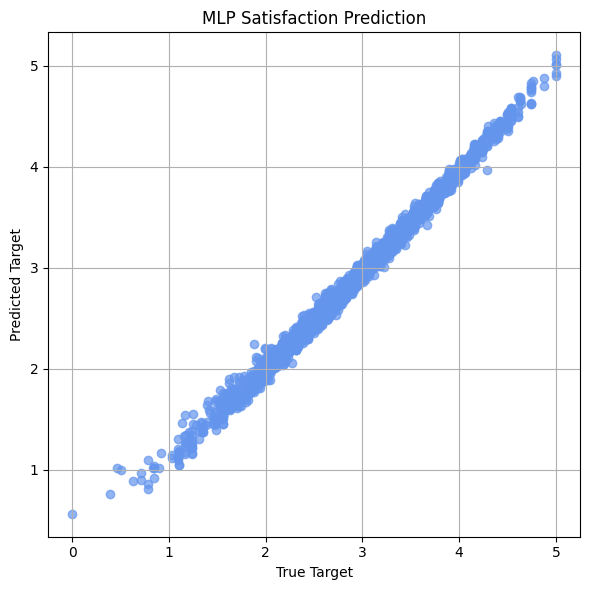

In [ ]:
# ================== 예측 및 시각화 ==================
import torch
import numpy as np
import matplotlib.pyplot as plt

# GPU 또는 CPU 선택
device = "cuda" if torch.cuda.is_available() else "cpu"

# 검증용 데이터 준비 (X_val이 이전에 정의되어 있어야 함)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)

# 모델 클래스 정의 (학습 때와 동일하게)
from torch import nn
class MLP(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.net(x)

# 모델 로드
model = MLP(X_val.shape[1]).to(device)
model.load_state_dict(torch.load("satisfaction_model.pth", map_location=device))
model.eval()

# 예측
with torch.no_grad():
    y_pred = model(X_val_tensor).cpu().numpy().flatten() * 5  # 스케일 복원
    y_true = y_val.flatten() * 5

# 시각화
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, color='cornflowerblue', alpha=0.7)
plt.xlabel("True Target")
plt.ylabel("Predicted Target")
plt.title("MLP Satisfaction Prediction")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# ───────────────────────────────
# 0. 경로 확인
CSV_PATH   = "/content/drive/MyDrive/AI/서울서베이_MinMax.csv"
META_PATH  = "/content/preprocess_meta.pkl"      # 이전 코드에서 저장한 메타
MODEL_PATH = "/content/satisfaction_model.pth"   # 저장된 MLP 가중치
# ───────────────────────────────

import pandas as pd, numpy as np, joblib, torch
from torch import nn

# 1. 전처리 메타 불러오기 ─────────────────────────────────────────
meta = joblib.load(META_PATH)
cont_cols      = meta["continuous_cols"]
cat_cols_full  = meta["categorical_cols"]        # 원본 범주 컬럼 목록
num_mean       = pd.Series(meta["num_mean"])
num_std        = pd.Series(meta["num_std"]).replace(0, 1)
onehot_columns = meta["cat_columns"]             # 학습 시 등장했던 원-핫 컬럼

# 2. MLP 아키텍처 정의 & 가중치 로드 ──────────────────────────────
class MLP(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.net(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = MLP(len(cont_cols) + len(onehot_columns)).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

# 3. 데이터 로드 & 자치구 대표 행 추출
df        = pd.read_csv(CSV_PATH, encoding="utf-8")
TARGET_COL = "종합만족도"

# 자치구별 대표 1행(첫 번째 응답)만 사용 -- 더 정교화 원하면 수정
X_gu = df.groupby("구코드").first().reset_index().drop(columns=[TARGET_COL])

# 4. 전처리 함수 (meta 사용)
def preprocess(frame: pd.DataFrame) -> np.ndarray:

    X_num = ((frame[cont_cols] - num_mean) / num_std).to_numpy(dtype=np.float32)


    frame_cat = frame[cat_cols_full].astype(str).fillna("없음")
    cat_dummy = pd.get_dummies(frame_cat).reindex(columns=onehot_columns, fill_value=0)
    X_cat = cat_dummy.to_numpy(dtype=np.float32)

    return np.hstack([X_num, X_cat])

# 5. 예측
X_enc      = preprocess(X_gu)
with torch.no_grad():
    y_pred = model(torch.tensor(X_enc, dtype=torch.float32).to(device))\
               .cpu().numpy().reshape(-1) * 5.0   # 0~5 스케일 복원

X_gu["예측_종합만족도"] = y_pred

# 6. 구이름
district_name = {110:"종로구",140:"중구",170:"용산구",200:"성동구",215:"광진구",
                 230:"동대문구",260:"중랑구",290:"성북구",305:"강북구",320:"도봉구",
                 350:"노원구",380:"은평구",410:"서대문구",440:"마포구",470:"양천구",
                 500:"강서구",530:"구로구",545:"금천구",560:"영등포구",590:"동작구",
                 620:"관악구",650:"서초구",680:"강남구",710:"송파구",740:"강동구"}
X_gu["구이름"] = X_gu["구코드"].map(district_name)

print("\n📊 자치구별 종합만족도 예측")
print(X_gu[["구코드", "구이름", "예측_종합만족도"]].sort_values("구코드").to_string(index=False))



📊 자치구별 종합만족도 예측
  구코드  구이름  예측_종합만족도
110.0  종로구  2.395308
140.0   중구  4.285848
170.0  용산구  3.193928
200.0  성동구  3.381336
215.0  광진구  3.069752
230.0 동대문구  3.125168
260.0  중랑구  3.299227
290.0  성북구  2.135820
305.0  강북구  3.619789
320.0  도봉구  3.595033
350.0  노원구  3.801917
380.0  은평구  3.175215
410.0 서대문구  2.476425
440.0  마포구  2.589468
470.0  양천구  2.908138
500.0  강서구  3.673912
530.0  구로구  2.806299
545.0  금천구  1.876574
560.0 영등포구  2.153111
590.0  동작구  2.603573
620.0  관악구  3.613391
650.0  서초구  2.887883
680.0  강남구  2.793020
710.0  송파구  2.202972
740.0  강동구  3.038594


In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, preds, color='steelblue')
plt.xlabel("True Target")
plt.ylabel("Predicted Target")
plt.title("MLP Satisfaction Prediction")
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

#PR커브


모델 성능 커브 & 지표:


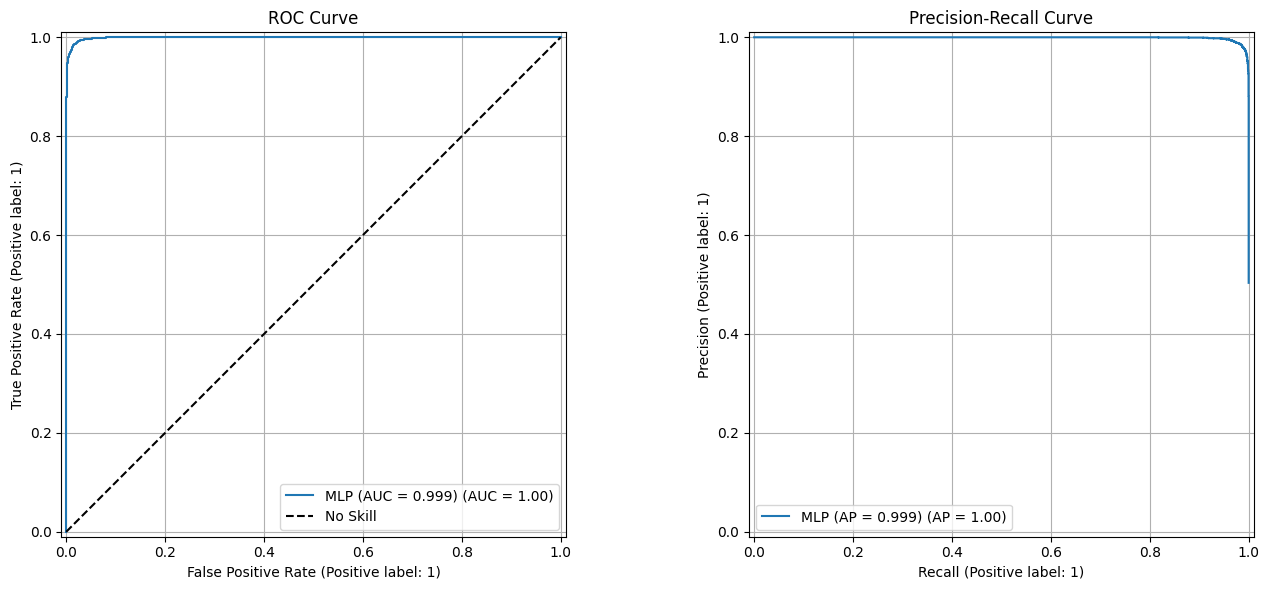

cut-off : 3.0  (norm=0.60)
Class counts : Counter({np.int64(1): 3613, np.int64(0): 3564})
Accuracy     : 0.9730
Precision    : 0.9968
Recall       : 0.9493
F1 Score     : 0.9725
ROC AUC Score: 0.9991


In [ ]:
# ======================================================================
# 8. 모델 성능 시각화 + 분류 지표  (cut-off 기반, 스케일 통일)
# ======================================================================
import numpy as np, matplotlib.pyplot as plt, torch
from sklearn.metrics import (
    PrecisionRecallDisplay, RocCurveDisplay,
    average_precision_score, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from collections import Counter

def plot_and_report(model, data_loader, device, cutoff=3.0):
    """
    • DataLoader에서 (X, y) = (batch, 1) → y는 0~1 스케일의 정답
    • cutoff 이상이면 '1'(만족), 미만이면 '0'(불만족)으로 이진화
    • ROC / PR 커브 + Accuracy, Precision, Recall, F1 모두 출력
    """
    model.eval()
    y_scores, y_true_cls = [], []

    cutoff_norm = cutoff / 5.0           # 3.0 → 0.6 (0~1 스케일)

    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            preds = model(xb).cpu().numpy().flatten()  # 0~1 예측 스코어
            y_scores.append(preds)

            # ★ 여기서 바로 '0/1' 라벨로 변환
            y_true_cls.append((yb.numpy().flatten() >= cutoff_norm).astype(int))

    y_scores   = np.concatenate(y_scores)      # 예측 확률(0~1)
    y_true_cls = np.concatenate(y_true_cls)    # 0/1 레이블

    # ── ROC & PR 곡선 ───────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    auc = roc_auc_score(y_true_cls, y_scores)
    RocCurveDisplay.from_predictions(
        y_true_cls, y_scores, ax=ax1,
        name=f"MLP (AUC = {auc:.3f})"
    )
    ax1.plot([0, 1], [0, 1], 'k--', label='No Skill')
    ax1.set_title('ROC Curve'); ax1.legend(); ax1.grid(True)

    ap = average_precision_score(y_true_cls, y_scores)
    PrecisionRecallDisplay.from_predictions(
        y_true_cls, y_scores, ax=ax2,
        name=f"MLP (AP = {ap:.3f})"
    )
    ax2.set_title('Precision-Recall Curve'); ax2.grid(True)

    plt.tight_layout(); plt.show()

    # ── cut-off 분류 지표 ───────────────────────────────────────
    y_pred_cls = (y_scores >= cutoff_norm).astype(int)

    print(f"cut-off : {cutoff}  (norm={cutoff_norm:.2f})")
    print("Class counts :", Counter(y_true_cls))
    print(f"Accuracy     : {accuracy_score(y_true_cls, y_pred_cls):.4f}")
    print(f"Precision    : {precision_score(y_true_cls, y_pred_cls):.4f}")
    print(f"Recall       : {recall_score(y_true_cls, y_pred_cls):.4f}")
    print(f"F1 Score     : {f1_score(y_true_cls, y_pred_cls):.4f}")
    print(f"ROC AUC Score: {auc:.4f}")
# ── 호출 예시 ─────────────────────────────────────────────────
print("\n모델 성능 커브 & 지표:")
plot_and_report(model, val_loader, device)   # 또는 test_loader


# Loss곡선

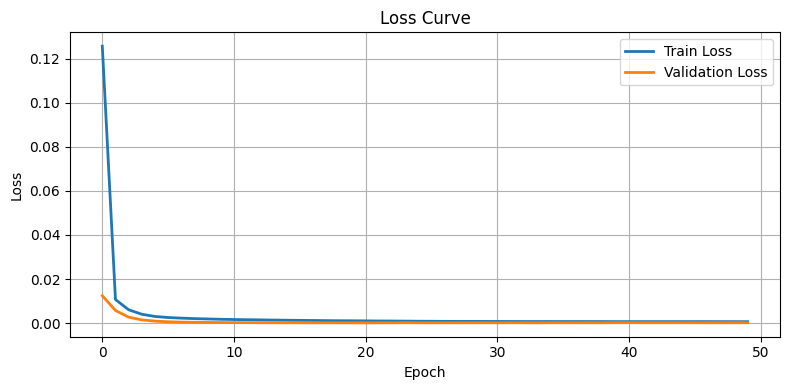

In [ ]:
# ================== 손실 곡선 시각화 ==================
import matplotlib.pyplot as plt
import numpy as np
import os

# 파일에서 불러오기
train_losses = np.load("train_losses.npy")
val_losses = np.load("val_losses.npy")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

# 이미지로 저장
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/loss_curve.png", dpi=150)
plt.show()


#위험요소 제거 후 재 학습

In [ ]:
# ==============================================================================
# 2. 데이터 준비 (데이터 유출 확인 로직 추가)
# ==============================================================================

# --- 파일 로드 (이전과 동일) ---
file_name = "/content/drive/MyDrive/AI/서울서베이_MinMax_Full_Encoded.csv"
try:
    df = pd.read_csv(file_name)
    print(f"'{file_name}' 파일 로드 성공. Shape: {df.shape}")
except FileNotFoundError:
    print(f"오류: '{file_name}' 파일을 찾을 수 없습니다.")
    raise SystemExit("데이터 파일 로드 실패")

if '종합만족도' not in df.columns:
    print(f"오류: '{file_name}' 파일에 '종합만족도' 컬럼이 없습니다.")
    raise SystemExit("'종합만족도' 컬럼 누락")

# ==================== ✨ 데이터 유출 확인 단계 ✨ ====================

# [확인 1] '종합만족도'와 다른 변수들 간의 상관관계 계산
# 'num__'으로 시작하는 연속형 변수만 선택하여 상관관계 분석
print("\n--- '종합만족도'와 상관관계 분석 ---")
numeric_features = [col for col in df.columns if col.startswith('num__')]
# 만약 'num__' 접두사가 없다면, 모든 숫자형 컬럼 선택
if not numeric_features:
    numeric_features = df.select_dtypes(include=np.number).columns.tolist()
    # 이미 제외할 컬럼들은 미리 제거
    numeric_features = [f for f in numeric_features if f not in ['종합만족도', 'target']]

correlations = df[numeric_features + ['종합만족도']].corr()['종합만족도'].sort_values(ascending=False)

print("상관관계 상위 10개:")
print(correlations.head(10))
print("\n상관관계 하위 10개 (음의 상관관계):")
print(correlations.tail(10))

# [확인 2] 데이터 유출이 의심되는 피처 목록 정의 (사용자가 직접 확인하고 수정)
# 방법 1: 상관계수 결과를 보고 직접 변수명 입력
# leaky_features_to_exclude = ['num__통근/통학 환경에 대한 전반적 만족도', 'num__녹지환경 만족도', 'num__야간 보행시 안전도', 'num__문화환경 만족도_문화시설']

# 방법 2: 컬럼 이름에 '만족도'나 '안전도' 같은 키워드가 포함된 경우 자동으로 제외
keywords_to_exclude = ['만족도', '안전도']
leaky_features_to_exclude = [
    col for col in df.columns
    if any(keyword in col for keyword in keywords_to_exclude) and col != '종합만족도'
]

print(f"\n제외할 데이터 유출 의심 피처 ({len(leaky_features_to_exclude)}개):")
print(leaky_features_to_exclude)

# 기존 `셀 2`의 "[확인 2] 데이터 유출이 의심되는 피처 목록 정의" 코드 바로 아래에 추가합니다.

# ==================== ✨ 추가 부분 시작 ✨ ====================

# [확인 3] 데이터 유출 의심 변수 21개의 상세 상관관계 확인
if leaky_features_to_exclude: # 리스트가 비어있지 않은 경우에만 실행
    print("\n--- 유출 의심 변수와 '종합만족도'의 상세 상관관계 ---")

    # 유출 의심 변수와 타겟 변수만 포함하여 상관관계 계산
    leaky_correlations = df[leaky_features_to_exclude + ['종합만족도']].corr()['종합만족도'].sort_values(ascending=False)

    # '종합만족도' 자체의 상관관계(1.0)는 제외하고 출력
    print(leaky_correlations.drop('종합만족도'))

# ==================== ✨ 추가 부분 끝 ✨ ====================

# 이어서 기존의 "최종적으로 모델 학습에 사용될 피처 개수:" 등의 코드가 실행됩니다.

# =====================================================================

# --- 타겟 변수 생성 및 피처/타겟 분리 (수정된 부분) ---
median_satisfaction = df['종합만족도'].median()
df['target'] = (df['종합만족도'] > median_satisfaction).astype(int)
print(f"\n'종합만족도' 중간값: {median_satisfaction:.4f}, 'target' 생성 (1: 높음, 0: 낮음)")

# 제외할 피처 목록에 기본 제외 목록('종합만족도', 'target')과 유출 의심 피처를 모두 추가
features_to_exclude = ['종합만족도', 'target'] + leaky_features_to_exclude
X_cols = [col for col in df.columns if col not in features_to_exclude]

print(f"\n최종적으로 모델 학습에 사용될 피처 개수: {len(X_cols)}")

X = df[X_cols].values.astype(np.float32)
y = df['target'].values.astype(np.float32)
print(f"피처 행렬 X 형태: {X.shape}, 타겟 벡터 y 형태: {y.shape}")

# 학습 데이터와 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
print(f"\nX_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

'/content/drive/MyDrive/AI/서울서베이_MinMax_Full_Encoded.csv' 파일 로드 성공. Shape: (35881, 239)

--- '종합만족도'와 상관관계 분석 ---
상관관계 상위 10개:
종합만족도                1.000000
num__통근/통학 시간_분      0.207864
num__일반주거지역          0.096745
num__초등학교_평균학생수      0.073363
num__녹지생산지역          0.072289
num__아파트_평균_전세보증금    0.069835
num__아파트_평균_월세가      0.069030
num__아파트_평균_월세보증금    0.068738
num__연립다세대_평균_월세가    0.067929
num__아파트_평균_매매가      0.066177
Name: 종합만족도, dtype: float64

상관관계 하위 10개 (음의 상관관계):
num__영화관수              -0.027933
num__준주거지역             -0.034050
num__녹지지연지역            -0.042252
num__5대범죄_건수           -0.045369
num__유통업계수             -0.045860
num__문화공간수             -0.052389
num__경찰서수              -0.054838
num__현재 사는 집 거주기간_개월   -0.058622
num__준공업지역             -0.061427
num__일반상업지역            -0.080221
Name: 종합만족도, dtype: float64

제외할 데이터 유출 의심 피처 (21개):
['cat__통근/통학 환경에 대한 전반적 만족도_0', 'cat__통근/통학 환경에 대한 전반적 만족도_1', 'cat__통근/통학 환경에 대한 전반적 만족도_2', 'cat__통근/통학 환경에 대한 전반적 만족도_3', 'cat__통

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# ─── PyTorch Dataset ───
class SurveyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # (N, 1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ─── DataLoader 생성 ───
train_dataset = SurveyDataset(X_train, y_train)
test_dataset  = SurveyDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

# ─── MLP 모델 정의 ───
class MLPBinaryClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# ─── 모델/손실함수/옵티마이저 준비 ───
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLPBinaryClassifier(X_train.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
import numpy as np
import torch.nn.utils as utils

train_losses = []
val_losses = []
best_loss = float('inf')

for epoch in range(1, 201):
    # ─── Training ───
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        train_loss += loss.item() * len(xb)

    avg_train_loss = train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # ─── Validation ───
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item() * len(xb)

    avg_val_loss = val_loss / len(test_loader.dataset)
    val_losses.append(avg_val_loss)

    print(f"[{epoch:02d}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # ─── Save Best Model ───
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), "best_binary_model.pth")
        print(f"✅ Best model saved at epoch {epoch} (val_loss={best_loss:.4f})")


[01] Train Loss: 0.5273 | Val Loss: 0.5867
✅ Best model saved at epoch 1 (val_loss=0.5867)
[02] Train Loss: 0.5228 | Val Loss: 0.5873
[03] Train Loss: 0.5240 | Val Loss: 0.5878
[04] Train Loss: 0.5237 | Val Loss: 0.5868
[05] Train Loss: 0.5203 | Val Loss: 0.5871
[06] Train Loss: 0.5203 | Val Loss: 0.5864
✅ Best model saved at epoch 6 (val_loss=0.5864)
[07] Train Loss: 0.5195 | Val Loss: 0.5870
[08] Train Loss: 0.5171 | Val Loss: 0.5872
[09] Train Loss: 0.5170 | Val Loss: 0.5878
[10] Train Loss: 0.5174 | Val Loss: 0.5879
[11] Train Loss: 0.5150 | Val Loss: 0.5882
[12] Train Loss: 0.5135 | Val Loss: 0.5881
[13] Train Loss: 0.5130 | Val Loss: 0.5881
[14] Train Loss: 0.5125 | Val Loss: 0.5883
[15] Train Loss: 0.5097 | Val Loss: 0.5890
[16] Train Loss: 0.5095 | Val Loss: 0.5902
[17] Train Loss: 0.5079 | Val Loss: 0.5896
[18] Train Loss: 0.5067 | Val Loss: 0.5901
[19] Train Loss: 0.5052 | Val Loss: 0.5918
[20] Train Loss: 0.5066 | Val Loss: 0.5907
[21] Train Loss: 0.5026 | Val Loss: 0.5907
[

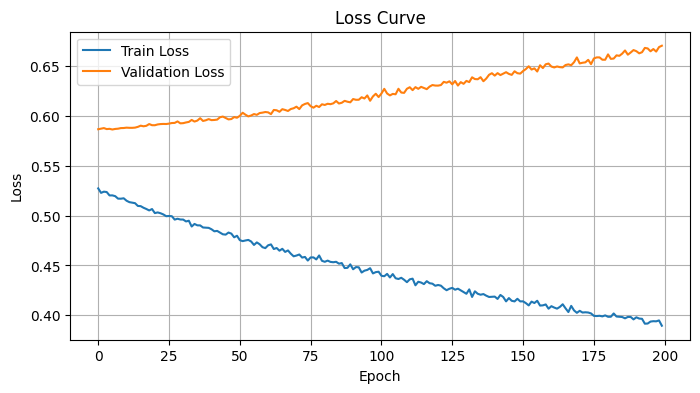

In [ ]:
import matplotlib.pyplot as plt

def plot_loss_curve(train_losses, val_losses):
    if not (len(train_losses) and len(val_losses)):
        raise ValueError("train_losses 혹은 val_losses 리스트가 비어 있습니다.")

    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

# 사용 예시 (학습 루프 이후에 호출)
plot_loss_curve(train_losses, val_losses)


In [ ]:
# ─── Best Model 로드 ───
model.load_state_dict(torch.load("best_binary_model.pth"))
model.eval()

# ─── 예측값 생성 ───
with torch.no_grad():
    X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    preds = model(X_tensor).cpu().numpy().reshape(-1)

# ─── 허용 오차 ±0.5 기준으로 실제 종합만족도 예측 여부 평가 ───
# y_test는 이미 이진 (0, 1), preds는 0~1 범위 확률값
threshold = 0.5
binary_preds = (preds > threshold).astype(int)

# ─── 성능 지표 계산 ───
TP = np.sum((binary_preds == 1) & (y_test == 1))
TN = np.sum((binary_preds == 0) & (y_test == 0))
FP = np.sum((binary_preds == 1) & (y_test == 0))
FN = np.sum((binary_preds == 0) & (y_test == 1))

accuracy  = (TP + TN) / len(y_test)
precision = TP / (TP + FP + 1e-8)
recall    = TP / (TP + FN + 1e-8)
f1_score  = 2 * precision * recall / (precision + recall + 1e-8)

print("\n📊 [최종 모델 평가 결과]")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_score:.4f}")

# ─── 혼동 행렬도 함께 출력 ───
print(f"\nConfusion Matrix:\n[[TN: {TN}  FP: {FP}]\n [FN: {FN}  TP: {TP}]]")



📊 [최종 모델 평가 결과]
Accuracy : 0.6933
Precision: 0.6856
Recall   : 0.6695
F1 Score : 0.6774

Confusion Matrix:
[[TN: 2665  FP: 1060]
 [FN: 1141  TP: 2311]]


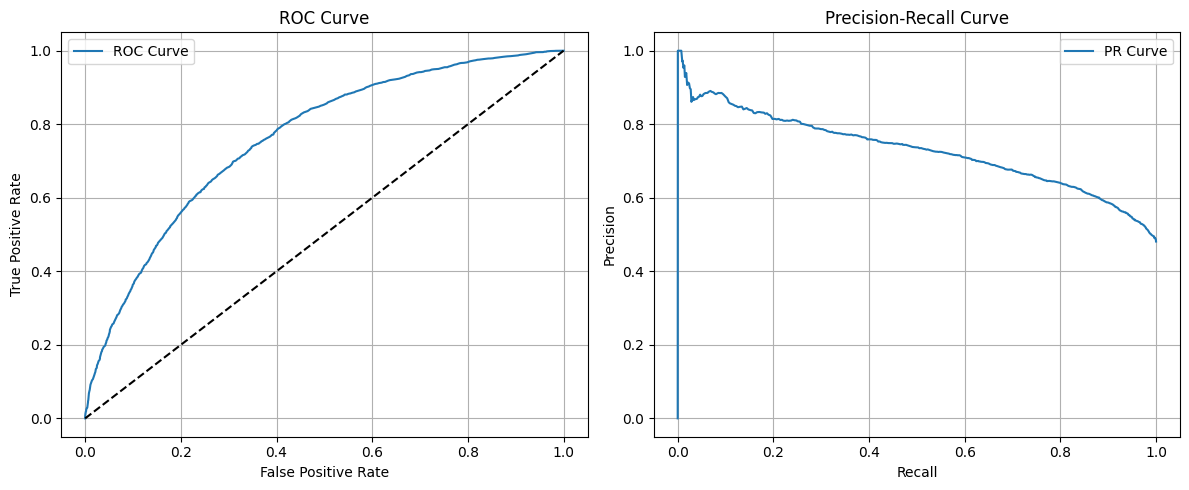

In [ ]:
# ============================ (5단계) ROC + PR Curve 시각화 ============================
import matplotlib.pyplot as plt

def plot_roc_pr(y_true, y_score):
    # ── ROC Curve 계산 ──
    def compute_roc_curve(y_true, y_score):
        thresholds = np.linspace(0, 1, 500)
        tpr_list = []
        fpr_list = []
        for thresh in thresholds:
            y_pred = (y_score >= thresh).astype(int)
            TP = np.sum((y_true == 1) & (y_pred == 1))
            TN = np.sum((y_true == 0) & (y_pred == 0))
            FP = np.sum((y_true == 0) & (y_pred == 1))
            FN = np.sum((y_true == 1) & (y_pred == 0))
            TPR = TP / (TP + FN + 1e-7)
            FPR = FP / (FP + TN + 1e-7)
            tpr_list.append(TPR)
            fpr_list.append(FPR)
        return fpr_list, tpr_list

    # ── PR Curve 계산 ──
    def compute_pr_curve(y_true, y_score):
        thresholds = np.linspace(0, 1, 500)
        precisions = []
        recalls = []
        for thresh in thresholds:
            y_pred = (y_score >= thresh).astype(int)
            TP = np.sum((y_true == 1) & (y_pred == 1))
            FP = np.sum((y_true == 0) & (y_pred == 1))
            FN = np.sum((y_true == 1) & (y_pred == 0))
            precision = TP / (TP + FP + 1e-7)
            recall = TP / (TP + FN + 1e-7)
            precisions.append(precision)
            recalls.append(recall)
        return recalls, precisions

    fpr, tpr = compute_roc_curve(y_true, y_score)
    recalls, precisions = compute_pr_curve(y_true, y_score)

    # ── 시각화 ──
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label="ROC Curve")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(recalls, precisions, label="PR Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# ── 실행 예시 ──
plot_roc_pr(y_test, preds)


In [ ]:
# ================== 0. 필수 패키지 ==================
import pandas as pd, numpy as np, joblib, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# ================== 1. CSV 경로 ==================
FILE_PATH = "/content/drive/MyDrive/AI/서울서베이_MinMax.csv"
TARGET_COL = "종합만족도"

# ================== 2. 데이터 로드 ==================
df = pd.read_csv(FILE_PATH, encoding="utf-8")

# 범주형/연속형 분리
cat_numeric = [
    "구코드", "주택형태", "주거점유형태", "통근/통학 여부", "통근/통학 지역",
    "통근/통학 지역_다른 구의 경우", "주로 이용하는 교통수단",
    "통근/통학 환경에 대한 전반적 만족도", "녹지환경 만족도", "야간 보행시 안전도",
    "문화환경 만족도_문화시설", "직업", "고용형태", "월평균 근로소득", "월평균 가구소득",
    "연령별", "학력별", "혼인상태별"
]
categorical_cols = list(dict.fromkeys(df.select_dtypes("object").columns.tolist() + cat_numeric))
continuous_cols = [c for c in df.columns if c not in categorical_cols + [TARGET_COL]]

df[categorical_cols] = df[categorical_cols].astype(str).fillna("없음")
df.replace({-1: np.nan, 99999: np.nan}, inplace=True)
df[continuous_cols] = df[continuous_cols].fillna(0)

# ================== 3. Train / Val 분리 ==================
np.random.seed(42)
perm = np.random.permutation(len(df))
split = int(len(df) * 0.8)
df_train, df_val = df.iloc[perm[:split]].copy(), df.iloc[perm[split:]].copy()

# ================== 4. 전처리 ==================
num_mean = df_train[continuous_cols].mean()
num_std  = df_train[continuous_cols].std().replace(0, 1)

def scale_num(df): return ((df[continuous_cols] - num_mean) / num_std).to_numpy(np.float32)

train_cat = pd.get_dummies(df_train[categorical_cols], dummy_na=False)
cat_columns = train_cat.columns

def encode_cat(df):
    cat = pd.get_dummies(df[categorical_cols], dummy_na=False)
    return cat.reindex(columns=cat_columns, fill_value=0).to_numpy(np.float32)

X_train = np.hstack([scale_num(df_train), encode_cat(df_train)])
X_val   = np.hstack([scale_num(df_val),   encode_cat(df_val)])
y_train = df_train[TARGET_COL].to_numpy(np.float32) / 5.0
y_val   = df_val[TARGET_COL].to_numpy(np.float32) / 5.0

# ================== 5. PyTorch Dataset ==================
class SurveyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(SurveyDataset(X_train, y_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(SurveyDataset(X_val, y_val), batch_size=256, shuffle=False)

# ================== 6. MLP 모델 정의 ==================
class MLP(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x): return self.net(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = MLP(X_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=4)

# ================== 7. 학습 루프 ==================
train_losses, val_losses = [], []
best_val = float("inf")

for epoch in range(1, 51):
    model.train(); t_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        t_loss += loss.item() * len(xb)
    t_loss /= len(train_loader.dataset)

    model.eval(); v_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            v_loss += criterion(model(xb), yb).item() * len(xb)
    v_loss /= len(val_loader.dataset)

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    scheduler.step(v_loss)

    print(f"[{epoch:02d}] Train={t_loss:.4f}  Val={v_loss:.4f}")
    if v_loss < best_val:
        best_val = v_loss
        torch.save(model.state_dict(), "satisfaction_model.pth")
        print(f"✔️ Best model saved (val={v_loss:.4f})")

# ================== 8. 전처리 메타 저장 ==================
preprocess_meta = {
    "continuous_cols": continuous_cols,
    "categorical_cols": categorical_cols,
    "num_mean": num_mean.to_dict(),
    "num_std": num_std.to_dict(),
    "cat_columns": cat_columns.tolist()
}
joblib.dump(preprocess_meta, "preprocess_meta.pkl")
print("✅ 모델: satisfaction_model.pth")
print("✅ 전처리 메타: preprocess_meta.pkl")


[01] Train=0.1278  Val=0.0118
✔️ Best model saved (val=0.0118)
[02] Train=0.0101  Val=0.0056
✔️ Best model saved (val=0.0056)
[03] Train=0.0058  Val=0.0028
✔️ Best model saved (val=0.0028)
[04] Train=0.0040  Val=0.0015
✔️ Best model saved (val=0.0015)
[05] Train=0.0031  Val=0.0010
✔️ Best model saved (val=0.0010)
[06] Train=0.0026  Val=0.0007
✔️ Best model saved (val=0.0007)
[07] Train=0.0022  Val=0.0005
✔️ Best model saved (val=0.0005)
[08] Train=0.0020  Val=0.0004
✔️ Best model saved (val=0.0004)
[09] Train=0.0019  Val=0.0003
✔️ Best model saved (val=0.0003)
[10] Train=0.0018  Val=0.0003
✔️ Best model saved (val=0.0003)
[11] Train=0.0017  Val=0.0003
✔️ Best model saved (val=0.0003)
[12] Train=0.0016  Val=0.0002
✔️ Best model saved (val=0.0002)
[13] Train=0.0015  Val=0.0002
✔️ Best model saved (val=0.0002)
[14] Train=0.0014  Val=0.0002
✔️ Best model saved (val=0.0002)
[15] Train=0.0013  Val=0.0002
✔️ Best model saved (val=0.0002)
[16] Train=0.0013  Val=0.0001
✔️ Best model saved (val=